# Colposcopy Lesion Segmentation — End-to-End Pipeline

Run every cell top to bottom, in order, on a fresh runtime (**Runtime -> Restart session and run all** if you're re-running after an earlier failed attempt — mixing a restarted runtime with leftover state from a previous one is exactly what caused the working-directory issues earlier).

**Before running:** Runtime -> Change runtime type -> T4 GPU (or better).


## 1. Setup: mount Drive (optional but recommended) and set the project root

In [ ]:
# Set to True to persist data/checkpoints/outputs across Colab sessions.
# Strongly recommended -- otherwise everything is wiped when the runtime recycles.
USE_DRIVE = True

import os

if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_ROOT = '/content/drive/MyDrive/colposcopy'
else:
    PROJECT_ROOT = '/content/colposcopy'

os.makedirs(PROJECT_ROOT, exist_ok=True)
os.chdir(PROJECT_ROOT)
print('Working directory set to:', os.getcwd())


Mounted at /content/drive
Working directory set to: /content/drive/MyDrive/colposcopy


## 2. Get the code
Set `REPO_URL` below to your GitHub repo (the one you added this notebook to), then run this cell. Opening a notebook from GitHub in Colab only loads that one file into the session -- it does NOT clone the rest of the repo onto the Colab VM, so `src/`, `configs/`, `requirements.txt`, and `data/manifest.csv` won't exist yet unless we pull them in explicitly, which is what this cell does.

No GitHub repo? Leave `REPO_URL = None` and it'll fall back to uploading `colposcopy_seg_pipeline.zip` from your computer instead.

In [ ]:
REPO_URL = 'https://github.com/Actulus/colp_seg'  # e.g. 'https://github.com/yourname/colposcopy-seg.git' -- set this to your repo

CODE_DIR = PROJECT_ROOT  # code lands directly in the project root

already_have_code = os.path.exists(os.path.join(CODE_DIR, 'src', 'train.py'))

if already_have_code:
    print('src/train.py already present, skipping fetch.')
elif REPO_URL:
    !git clone "{REPO_URL}" "{CODE_DIR}/_repo_tmp"
    # move contents up so paths match the rest of this notebook
    # (skip if your repo IS the project root already, i.e. no nested folder)
    !cp -rn "{CODE_DIR}/_repo_tmp"/* "{CODE_DIR}/" 2>/dev/null || true
    !rm -rf "{CODE_DIR}/_repo_tmp"
else:
    ZIP_PATH = '/content/colposcopy_seg_pipeline.zip'
    if not os.path.exists(ZIP_PATH):
        try:
            from google.colab import files
            print('Zip not found at', ZIP_PATH, '-- pick it from your computer:')
            uploaded = files.upload()
            ZIP_PATH = '/content/' + next(iter(uploaded))
        except ImportError:
            raise FileNotFoundError(
                f'Set REPO_URL above, or upload the zip to {ZIP_PATH} first.')
    !unzip -o "{ZIP_PATH}" -d "{CODE_DIR}"

# sanity check -- must show real files, not an empty/missing folder
!ls "{CODE_DIR}/src"

src/train.py already present, skipping fetch.
dataset.py		     inspect_results.py  prepare_data.py  train.py
diagnose_grade_breakdown.py  losses.py		 __pycache__
evaluate.py		     model.py		 train_kfold.py


## 3. Get the data
Clones straight into `PROJECT_ROOT/annocerv_raw` (skips if already present, e.g. from a previous session on the same Drive). The sanity-check `ls` confirms the path `prepare_data.py` needs actually exists **before** we rely on it -- this is exactly the check that would have caught the earlier working-directory mismatch immediately instead of two cells later.

In [ ]:
RAW_DIR = os.path.join(PROJECT_ROOT, 'annocerv_raw')

if not os.path.exists(os.path.join(RAW_DIR, 'dataset', 'swede_scores.csv')):
    !git clone --depth=1 https://github.com/iclx/AnnoCerv "{RAW_DIR}"
else:
    print('annocerv_raw already present, skipping clone.')

# sanity check -- must print a real file, not an error, before continuing
!ls -la "{RAW_DIR}/dataset/swede_scores.csv"


annocerv_raw already present, skipping clone.
-rw------- 1 root root 302 Aug 11 09:07 /content/drive/MyDrive/colposcopy/annocerv_raw/dataset/swede_scores.csv


## 3b. Get Atlas data (high/low-grade classification aux data + Kolposzkopia holdout)


In [ ]:
ATLAS_DIR = os.path.join(PROJECT_ROOT, 'atlas_raw')

# check all three subfolders prepare_data.py / inspect_kolposzkopia.py need,
# not just one -- a partial/interrupted clone could leave some but not others
_atlas_ready = all(os.path.exists(os.path.join(ATLAS_DIR, sub))
                    for sub in ('images_high_grade', 'images_low_grade', 'Kolposzkopia'))

if not _atlas_ready:
    !git clone --depth=1 https://github.com/erboro97/colposcopy-digital-atlas-dataset "{ATLAS_DIR}"
else:
    print('atlas_raw already present, skipping clone.')

In [ ]:
# sanity check -- must print real files/dirs, not an error, before continuing
!ls -la "{ATLAS_DIR}/images_high_grade" | head -3
!ls -la "{ATLAS_DIR}/images_low_grade" | head -3
!ls -la "{ATLAS_DIR}/Kolposzkopia" | head -3

## 4. Install dependencies

In [ ]:
%cd {PROJECT_ROOT}
!pip install -q -r requirements.txt


/content


## 5. Prepare data (unify + parse masks + case-level split)
Fast, CPU-only, a couple minutes. Re-run any time you change `--swede_threshold` or crop settings -- it's fully deterministic and safe to overwrite.

In [ ]:
!python src/prepare_data.py --raw_dir "{RAW_DIR}/dataset" --atlas_dir "{ATLAS_DIR}" --out_dir data --swede_threshold 5

Building manifest from /content/drive/MyDrive/colposcopy/annocerv_raw/dataset ...
  532 total image rows across 100 cases
  297 rows have an annotation mask (55.8%)
Parsing annotation overlays into binary lesion masks ...
  50/297 masks parsed
  100/297 masks parsed
  150/297 masks parsed
  200/297 masks parsed
  250/297 masks parsed
  297/297 masks parsed
  NOTE: 85 annotation PNGs parsed to an EMPTY mask (no colored strokes found above threshold) — these are cases the clinician marked as having no notable lesion features. Kept as valid negative-mask examples, not dropped.
Splitting by case (train/val/test = 70/15/15, stratified by label) ...
  train:  69 cases,  357 images,  197 with masks, pos.rate(cls)=0.41
  val  :  16 cases,   82 images,   44 with masks, pos.rate(cls)=0.45
  test :  15 cases,   93 images,   56 with masks, pos.rate(cls)=0.41

Wrote manifest: data/manifest.csv
Wrote stats: data/prepare_stats.json


## 6. Train
Uses GPU automatically if available (check the first printed line says `Device: cuda`, not `Device: cpu` -- if it says cpu, fix the runtime type in Runtime -> Change runtime type before continuing). Checkpoints save to `outputs/best_model.pt` every time val_dice improves, so an interrupted run doesn't lose progress -- you can lower `training.epochs` in `configs/config.yaml` and re-run this cell to continue experimenting without waiting for the full 100 every time.

In [ ]:
!python src/train.py --config configs/config.yaml


Device: cuda
train=357 val=82
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Computed pos_weights from TRAIN split: cls=1.45 seg=15.00
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100% 83.3M/83.3M [00:00<00:00, 123MB/s]
/content/drive/MyDrive/colposcopy/src/train.py:195: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if (device.type == "cuda" and cfg["trainin

## 7. Evaluate on the held-out test set

In [ ]:
!python src/evaluate.py --config configs/config.yaml


Calibrating threshold on VAL...
  best threshold = 0.75  (val dice = 0.3434)
Evaluating on TEST at that threshold...
{
  "checkpoint": "outputs/best_model.pt",
  "calibrated_threshold": 0.7500000000000002,
  "n_test_samples": 56,
  "test_dice_mean": 0.33834341896977227,
  "test_dice_95ci": [
    0.22694880875841403,
    0.45837075413192874
  ],
  "test_iou_mean": 0.32847310173737637,
  "test_iou_95ci": [
    0.2167361961171596,
    0.4487348568711571
  ],
  "test_hd95_mean_px": 108.33816069071591,
  "test_hd95_n_valid": 5,
  "dice_by_grade": {
    "low": 0.3733509800935735,
    "high": 0.291666670804704
  },
  "threshold_sweep": [
    [
      0.1,
      0.07321039587259293
    ],
    [
      0.15000000000000002,
      0.08033954352140427
    ],
    [
      0.20000000000000004,
      0.08505833894014359
    ],
    [
      0.25000000000000006,
      0.08459470421075821
    ],
    [
      0.30000000000000004,
      0.10441079263421091
    ],
    [
      0.3500000000000001,
      0.1021755

## 8. Inspect results: training curves + real prediction overlays
This is the important one -- don't stop at the Dice number above. Generates `outputs/training_curves.png` and `outputs/qualitative_predictions_test.png`.

In [ ]:
!python src/inspect_results.py --config configs/config.yaml --n_samples 8


Wrote outputs/training_curves.png  (best val_dice=0.305 @ epoch 7)
Loaded checkpoint from epoch 7, val_dice=0.3050
Using calibrated threshold from evaluate.py: 0.75
Wrote outputs/qualitative_predictions_test.png


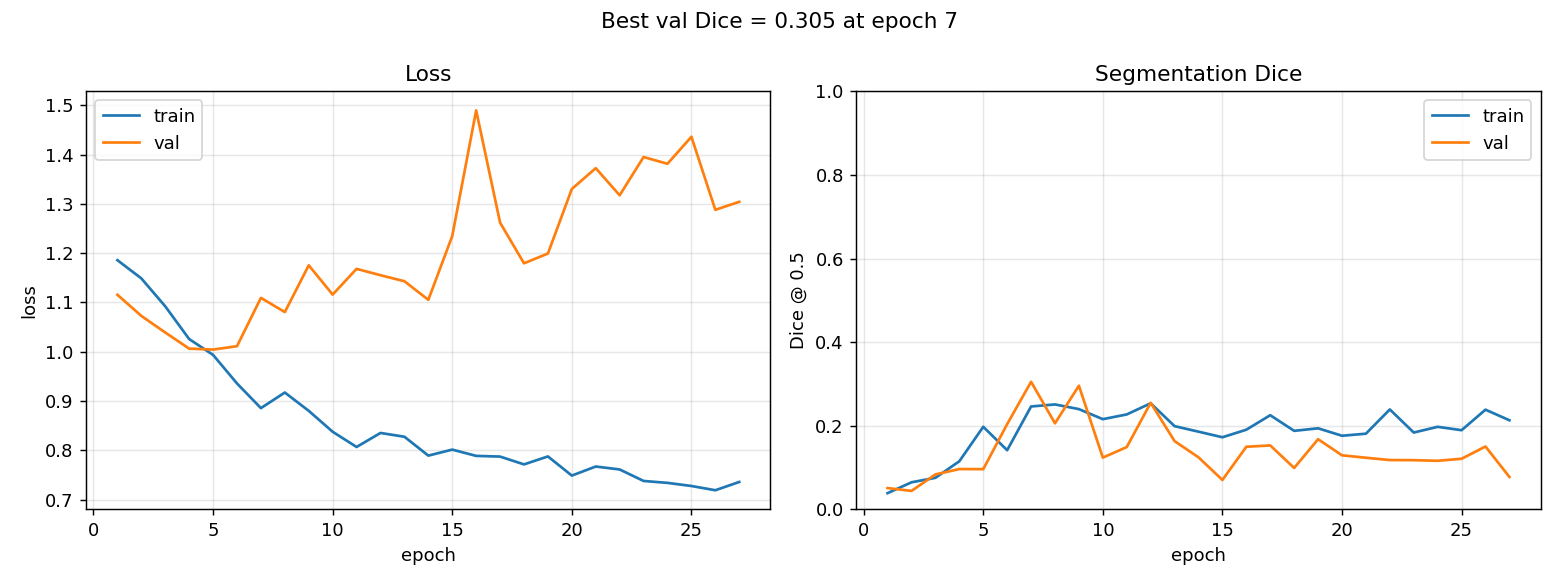

In [ ]:
import os
assert os.path.exists('outputs/training_curves.png'), (
    'training_curves.png missing -- the cell above must have errored; '
    'scroll up and check its output before continuing.'
)
from IPython.display import Image, display
display(Image('outputs/training_curves.png'))


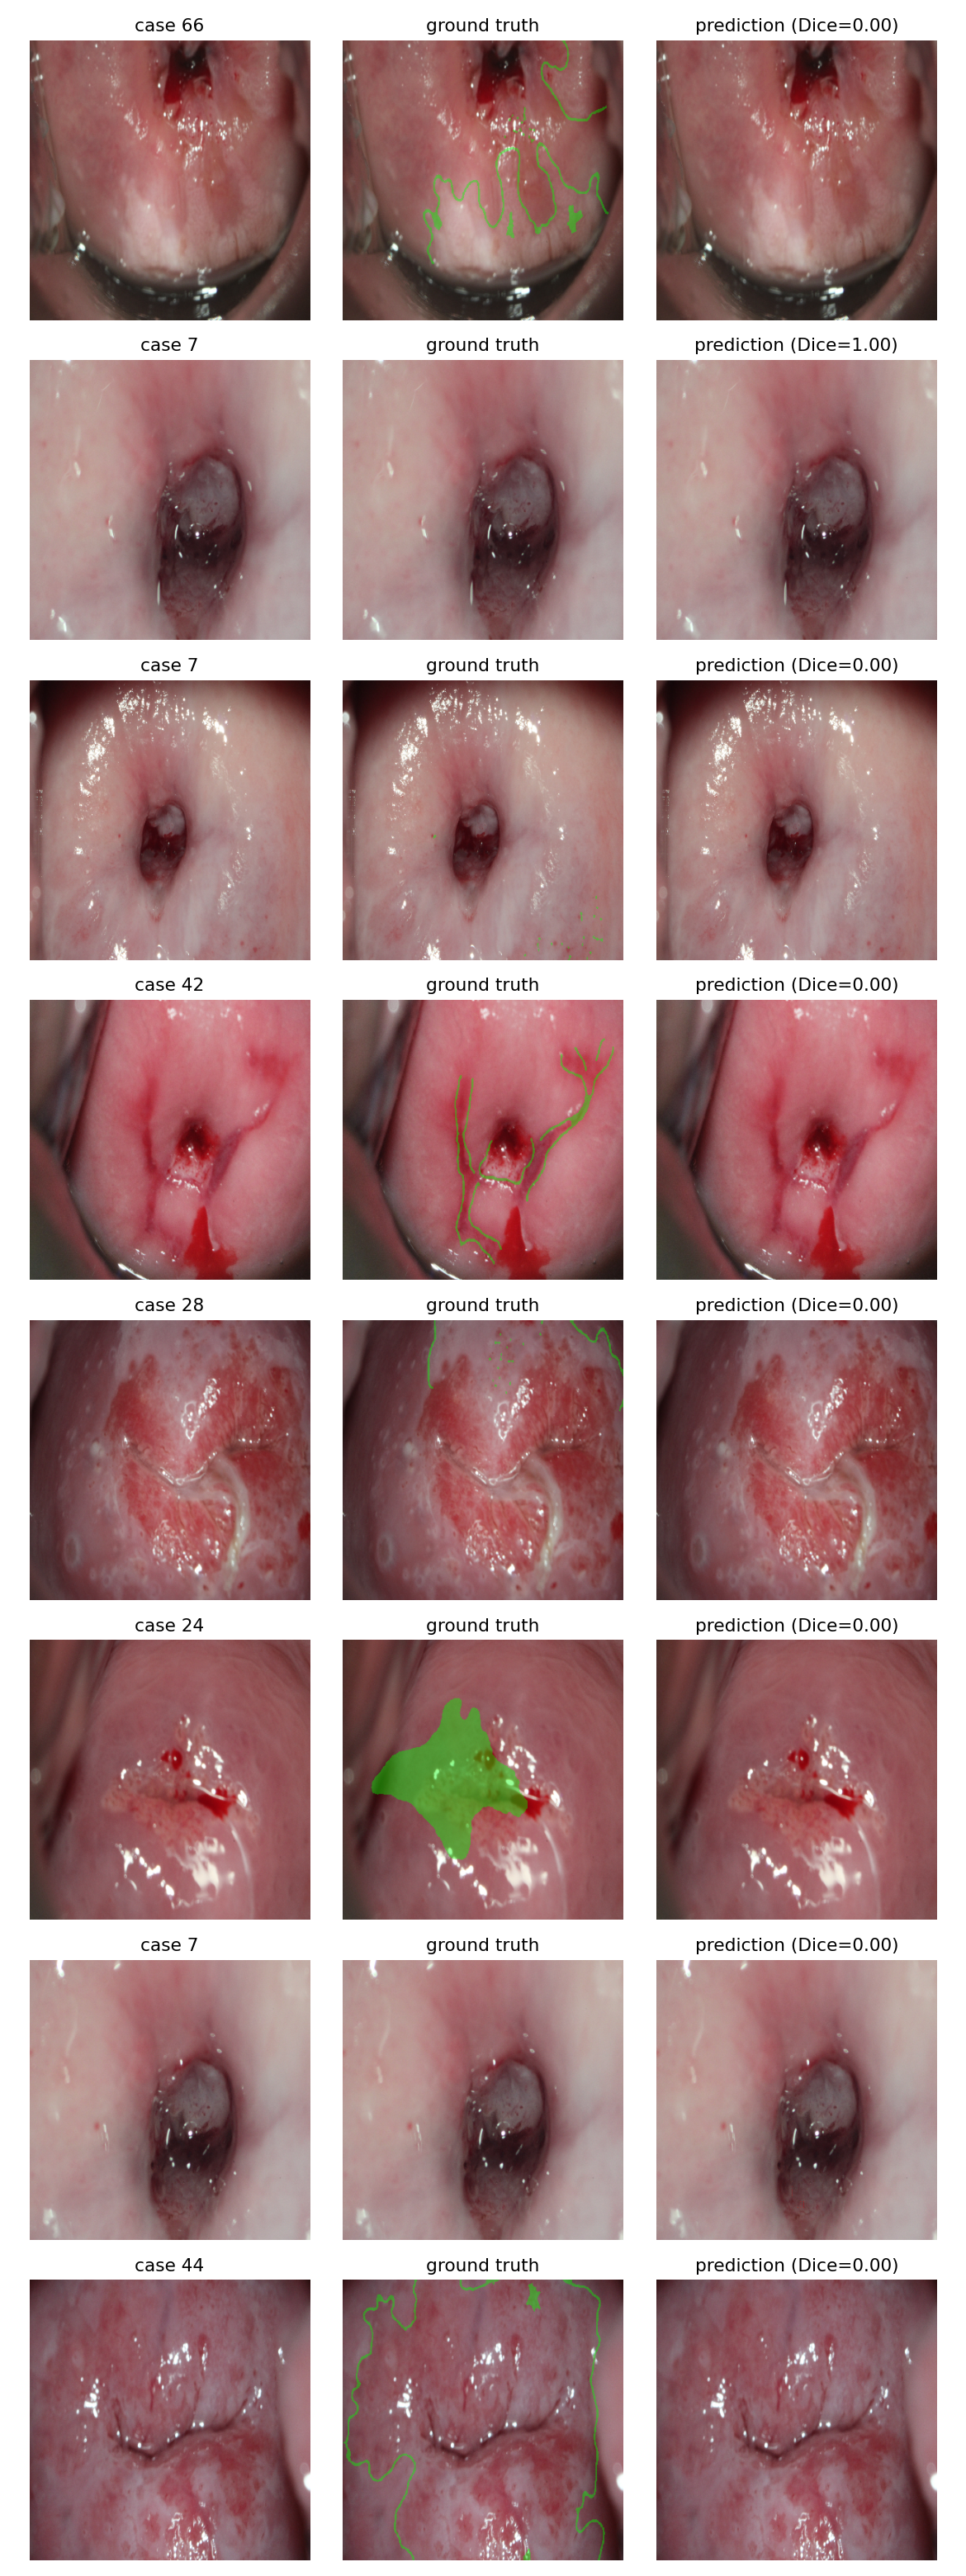

In [ ]:
display(Image('outputs/qualitative_predictions_test.png'))


## 9. Full numeric results
`dice_by_grade` is the number worth checking most closely -- confirms whether high-grade lesions (the clinically important ones) are being segmented at least as well as low-grade, not worse.

In [ ]:
import json
results = json.load(open('outputs/test_results.json'))
print(json.dumps(results, indent=2))


{
  "checkpoint": "outputs/best_model.pt",
  "calibrated_threshold": 0.7500000000000002,
  "n_test_samples": 56,
  "test_dice_mean": 0.33834341896977227,
  "test_dice_95ci": [
    0.22694880875841403,
    0.45837075413192874
  ],
  "test_iou_mean": 0.32847310173737637,
  "test_iou_95ci": [
    0.2167361961171596,
    0.4487348568711571
  ],
  "test_hd95_mean_px": 108.33816069071591,
  "test_hd95_n_valid": 5,
  "dice_by_grade": {
    "low": 0.3733509800935735,
    "high": 0.291666670804704
  },
  "threshold_sweep": [
    [
      0.1,
      0.07321039587259293
    ],
    [
      0.15000000000000002,
      0.08033954352140427
    ],
    [
      0.20000000000000004,
      0.08505833894014359
    ],
    [
      0.25000000000000006,
      0.08459470421075821
    ],
    [
      0.30000000000000004,
      0.10441079263421091
    ],
    [
      0.3500000000000001,
      0.10217552087237554
    ],
    [
      0.40000000000000013,
      0.09956231895238017
    ],
    [
      0.45000000000000007,


In [ ]:
import pandas as pd
history = pd.read_csv('outputs/training_history.csv')
pd.set_option('display.max_rows', None)
history


,epoch,time_s,train_loss,train_seg_loss,train_cls_loss,train_dice@0.5,val_loss,val_seg_loss,val_cls_loss,val_dice@0.5,lr_encoder,lr_decoder
0,1,120.1,1.185881,0.937516,0.827884,0.038527,1.115638,0.868390,0.824159,0.050692,0.000010,0.000102
1,2,47.0,1.148943,0.907377,0.805222,0.064442,1.072775,0.823574,0.830669,0.043857,0.000020,0.000202
2,3,42.5,1.092210,0.863496,0.762379,0.075238,1.039080,0.789984,0.830318,0.083333,0.000030,0.000300
3,4,47.1,1.025759,0.821419,0.681134,0.114823,1.006330,0.769300,0.790100,0.096185,0.000030,0.000300
4,5,45.5,0.993605,0.809883,0.612405,0.197333,1.004386,0.751915,0.841571,0.095934,0.000030,0.000300
5,6,43.5,0.935677,0.776099,0.531927,0.141288,1.011278,0.734457,0.922735,0.203701,0.000030,0.000299
6,7,46.3,0.885589,0.738371,0.490727,0.245956,1.109360,0.812208,0.990508,0.304977,0.000030,0.000299
7,8,47.8,0.917225,0.775421,0.472680,0.250838,1.080559,0.785083,0.984919,0.205665,0.000030,0.000298
8,9,45.6,0.880034,0.756394,0.412134,0.239651,1.175470,0.888986,0.954946,0.295727,0.000030,0.000297
9,10,43.9,0.837553,0.727435,0.367060,0.215550,1.116101,0.816968,0.997111,0.123568,0.000030,0.000296


## 10. (Optional) Inspect train/val predictions too
Same qualitative grid, but on splits the model *has* seen -- useful for spotting overfitting: if train predictions look great and val/test don't, that's the gap to close (more data, more augmentation, more dropout), not a threshold-tuning problem.

Wrote outputs/training_curves.png  (best val_dice=0.305 @ epoch 7)
Loaded checkpoint from epoch 7, val_dice=0.3050
Using calibrated threshold from evaluate.py: 0.75
Wrote outputs/qualitative_predictions_train.png


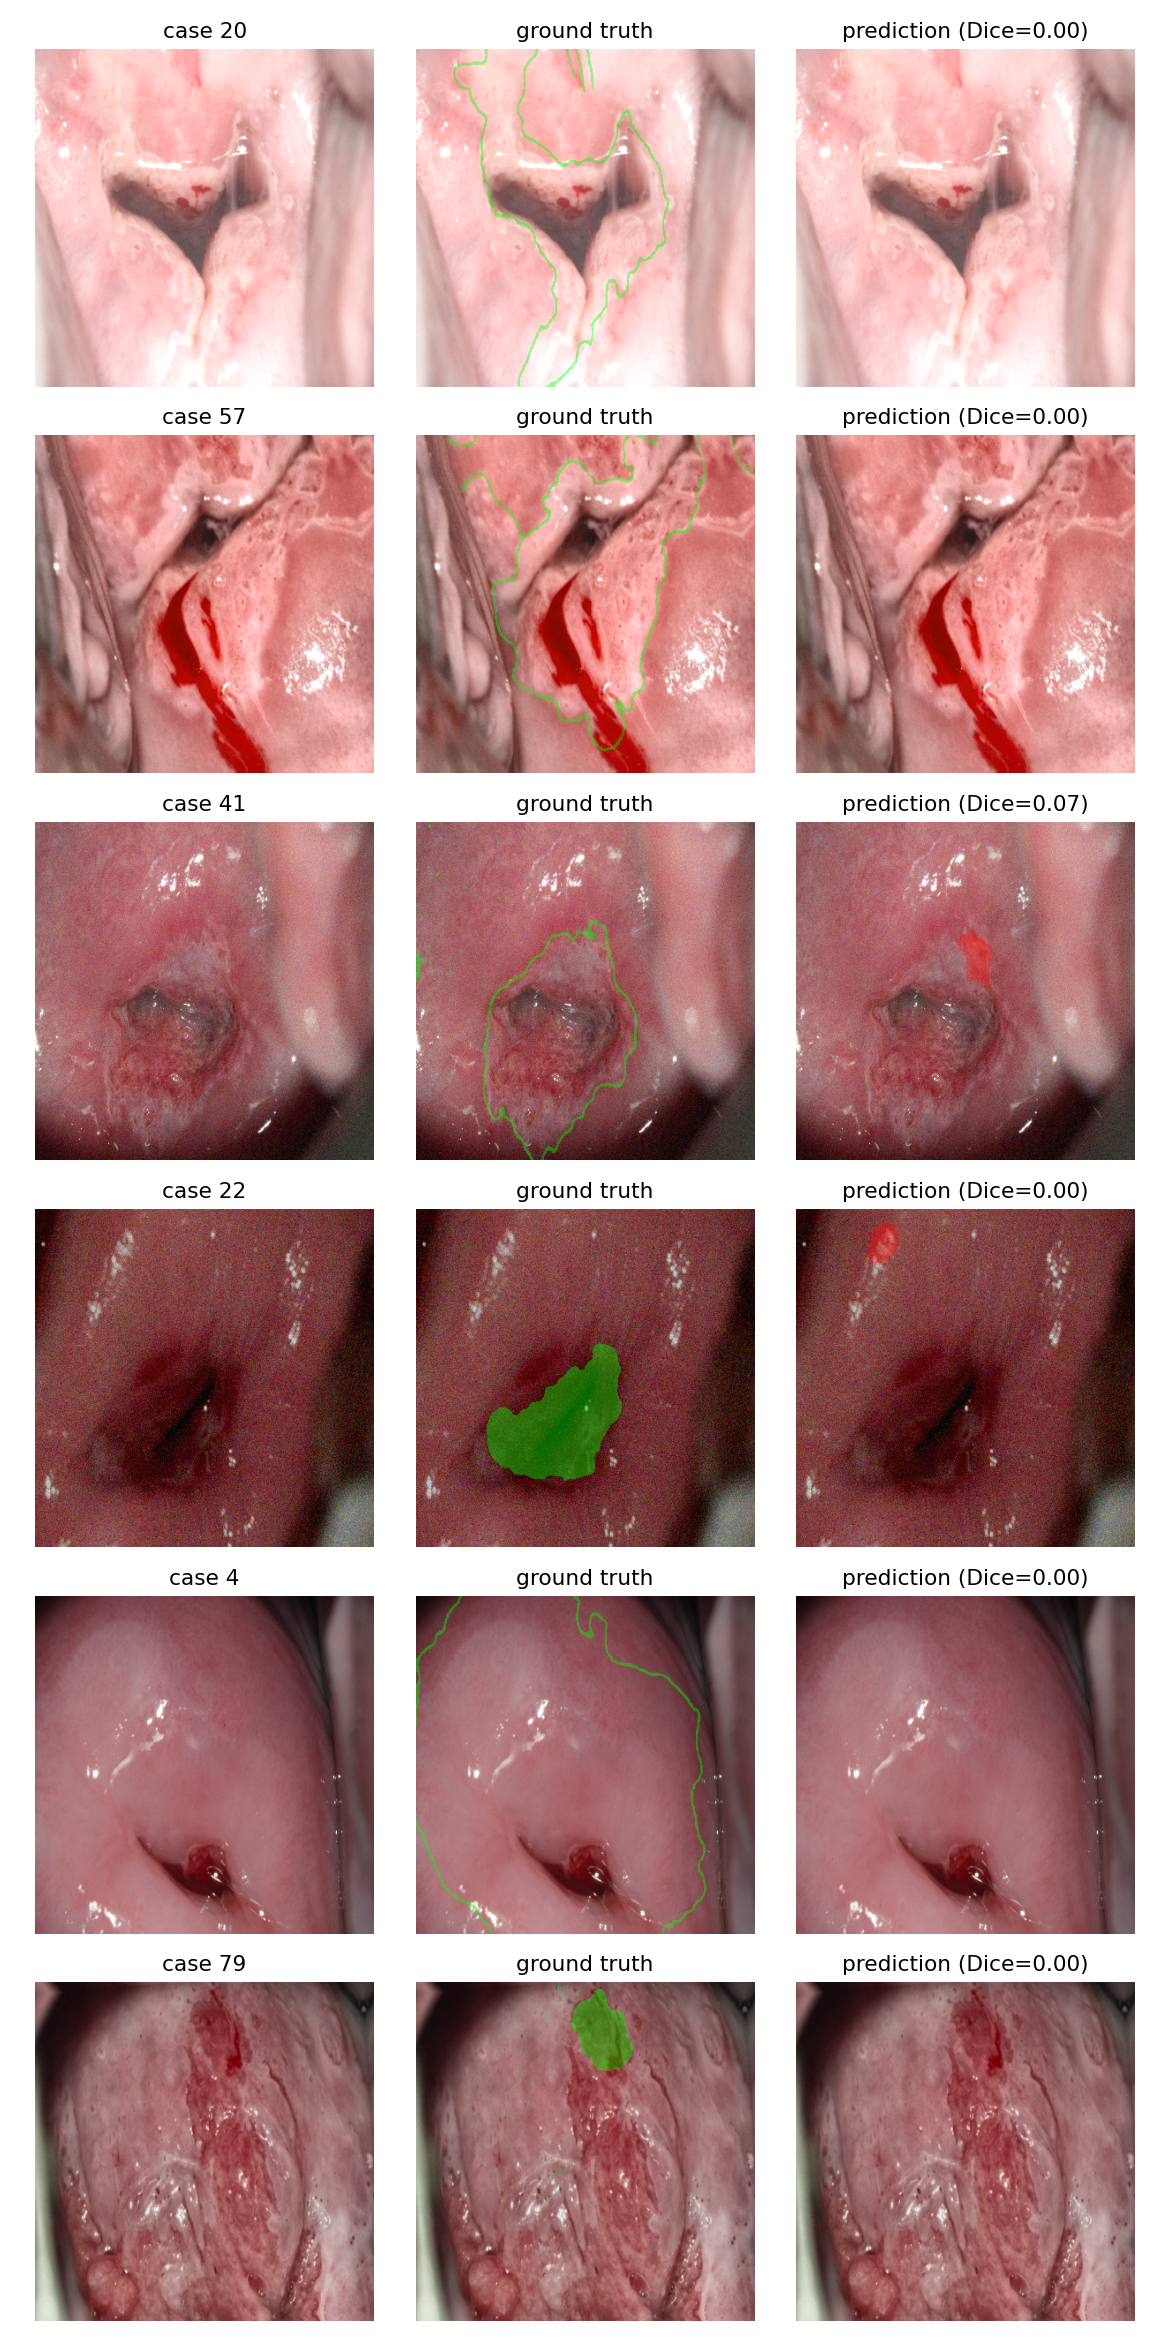

In [ ]:
!python src/inspect_results.py --config configs/config.yaml --n_samples 6 --split train
display(Image('outputs/qualitative_predictions_train.png'))


## 11. Kolposzkopia qualitative check (no ground truth -- eyeball only)
Runs inference on the 21-case Kolposzkopia holdout. Deliberately uses a
LOW threshold override rather than the calibrated one from evaluate.py --
that threshold was tuned on a very different, class-imbalanced eval set
and is likely far too conservative for an exploratory out-of-domain check.

In [ ]:
!python src/inspect_kolposzkopia.py --config configs/config.yaml --kolposzkopia_dir "{ATLAS_DIR}/Kolposzkopia" --threshold 0.3

In [ ]:
import glob
for p in sorted(glob.glob('outputs/kolposzkopia_predictions_page*.png')):
    display(Image(p))

## 12. K-fold cross-validation (optional, ~2.5-4 hours for 5 folds)
Independent of the single-split train/evaluate/inspect cells above — this
retrains from scratch, K times, and doesn't reuse `outputs/best_model.pt`.
Only needs the code + data cells (1-5) to have run first.

In [ ]:
!python src/train_kfold.py --config configs/config.yaml --n_folds 5

Device: cuda

=== Fold 1/5 ===
  train=68 cases, val=12 cases, test=20 cases
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100% 83.3M/83.3M [00:00<00:00, 229MB/s]
/content/drive/MyDrive/colposcopy/src/train_kfold.py:114: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if (device.type == "cuda" and cfg["training"]["

In [ ]:
import json
summary = json.load(open('outputs_kfold/kfold_summary.json'))
print(json.dumps(summary, indent=2))

import pandas as pd
pd.read_csv('outputs_kfold/kfold_results.csv')

{
  "n_folds": 5,
  "test_dice_mean": 0.27202175734419826,
  "test_dice_std": 0.07898351134810332,
  "test_iou_mean": 0.2550065898254932,
  "test_iou_std": 0.08602018468339967,
  "dice_by_grade_low_mean": 0.4176844441898827,
  "dice_by_grade_low_std": 0.14993782398840208,
  "dice_by_grade_high_mean": 0.04823633469314726,
  "dice_by_grade_high_std": 0.06204303928157937,
  "per_fold": [
    {
      "fold": 0,
      "best_val_dice": 0.1274430751800537,
      "calibrated_threshold": 0.5500000000000002,
      "n_test_samples": 61,
      "test_dice_mean": 0.2977496527509824,
      "test_iou_mean": 0.2477586851707583,
      "test_hd95_mean_px": 114.66193339590106,
      "test_hd95_n_valid": 38,
      "dice_by_grade_low": 0.4056489800422434,
      "dice_by_grade_high": 0.13140485651028852
    },
    {
      "fold": 1,
      "best_val_dice": 0.3430817425251007,
      "calibrated_threshold": 0.7500000000000002,
      "n_test_samples": 57,
      "test_dice_mean": 0.33467403183911687,
      "test_

,fold,best_val_dice,calibrated_threshold,n_test_samples,test_dice_mean,test_iou_mean,test_hd95_mean_px,test_hd95_n_valid,dice_by_grade_low,dice_by_grade_high
0,0,0.127443,0.55,61,0.297750,0.247759,114.661933,38,0.405649,0.131405
1,1,0.343082,0.75,57,0.334674,0.334020,146.636462,7,0.528128,0.003038
2,2,0.290701,0.70,64,0.284813,0.277854,123.392613,8,0.478996,0.001006
3,3,0.422261,0.50,68,0.134589,0.112033,148.713591,42,0.163084,0.098495
4,4,0.192955,0.55,47,0.308284,0.303368,279.841683,11,0.512565,0.007238


In [ ]:
!python src/diagnose_grade_breakdown.py --config configs/config.yaml

Device: cuda
  fold 0: evaluating at threshold=0.55 ...
  fold 1: evaluating at threshold=0.75 ...
  fold 2: evaluating at threshold=0.70 ...
  fold 3: evaluating at threshold=0.50 ...
  fold 4: evaluating at threshold=0.55 ...

=== Per-fold breakdown ===
 fold grade  gt_status  n  dice_mean  hit_rate
    0  high empty_mask  2      0.500     0.500
    0  high has_lesion 22      0.098     0.455
    0   low empty_mask 12      0.583     0.583
    0   low has_lesion 25      0.320     0.760
    1  high has_lesion 21      0.003     0.095
    1   low empty_mask 19      1.000     1.000
    1   low has_lesion 17      0.001     0.059
    2  high has_lesion 26      0.001     0.038
    2   low empty_mask 17      1.000     1.000
    2   low has_lesion 21      0.057     0.190
    3  high empty_mask  6      0.333     0.333
    3  high has_lesion 24      0.040     0.583
    3   low empty_mask 12      0.250     0.250
    3   low has_lesion 26      0.123     0.731
    4  high has_lesion 19      0.007   